In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=1bfa41967e2366101877aa850fad4620ca813865ada9c9a52aac10ab58eb793c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
!pip install timm seaborn


In [ ]:
!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install grad-cam timm --upgrade

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 54.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 44.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 19.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 29.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 32.7 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


In [ ]:
import sys
import pkg_resources
# Force Python to refresh its knowledge of installed packages
pkg_resources.working_set = pkg_resources.WorkingSet()

/tmp/ipython-input-1032944186.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


# New section

In [ ]:
import os
import pandas as pd
from google.colab import drive
from pathlib import Path

# ===============================
# 1. Mount Google Drive
# ===============================
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/ROP"
STAGE_DATA_CSV = os.path.join(BASE_DIR, "stage_data.csv")

# Define existing folder paths
IMAGE_DIRS = {
    0: os.path.join(BASE_DIR, "Normal"),
    1: os.path.join(BASE_DIR, "Mild"),
    2: os.path.join(BASE_DIR, "Severe")
}

MASK_DIRS = {
    0: os.path.join(BASE_DIR, "unet_masks/Normal"),
    1: os.path.join(BASE_DIR, "unet_masks/Mild"),
    2: os.path.join(BASE_DIR, "unet_masks/Severe")
}

# ===============================
# 2. Load Clinical Lookup (Metadata)
# ===============================
print("\nLoading clinical reference data from existing stage_data.csv...")
id_lookup, ga_lookup, bw_lookup = {}, {}, {}
global_ga, global_bw = 31, 1600 # Fallbacks

if os.path.exists(STAGE_DATA_CSV):
    ref_df = pd.read_csv(STAGE_DATA_CSV)

    # Standardize filenames for matching
    def get_clean_stem(path):
        fname = os.path.basename(str(path).replace('\\', '/'))
        return os.path.splitext(fname)[0].strip()

    # Create dictionaries for fast lookup
    # Using the stem of the image filename as the key
    ref_df['stem'] = ref_df['image_path'].apply(get_clean_stem)

    id_lookup = dict(zip(ref_df['stem'], ref_df['patient_id']))
    ga_lookup = dict(zip(ref_df['stem'], ref_df['ga']))
    bw_lookup = dict(zip(ref_df['stem'], ref_df['bw']))

    global_ga = ref_df['ga'].mean()
    global_bw = ref_df['bw'].mean()
    print(f"Loaded {len(ref_df)} clinical records.")
else:
    print("Warning: stage_data.csv not found. Metadata will be missing.")

# ===============================
# 3. Scan Folders and Build Dataset
# ===============================
all_rows = []
valid_exts = ('.jpg', '.jpeg', '.png')

for label, img_folder in IMAGE_DIRS.items():
    mask_folder = MASK_DIRS[label]

    if not os.path.exists(img_folder):
        print(f"Skipping missing folder: {img_folder}")
        continue

    print(f"Processing Stage {label} ({os.path.basename(img_folder)})...")

    # Index masks in this folder for fast matching
    mask_map = {}
    if os.path.exists(mask_folder):
        for m_file in os.listdir(mask_folder):
            if m_file.lower().endswith('.png'):
                stem = os.path.splitext(m_file)[0]
                mask_map[stem] = os.path.join(mask_folder, m_file)

    # Match images to masks
    for img_file in os.listdir(img_folder):
        if img_file.lower().endswith(valid_exts):
            img_path = os.path.join(img_folder, img_file)
            stem = os.path.splitext(img_file)[0]

            mask_path = mask_map.get(stem)

            if mask_path:
                all_rows.append({
                    'patient_id': id_lookup.get(stem, "Unknown"),
                    'image_path': img_path,
                    'mask_path': mask_path,
                    'ga': ga_lookup.get(stem, global_ga),
                    'bw': bw_lookup.get(stem, global_bw),
                    'label': label
                })

# ===============================
# 4. Save and Report
# ===============================
final_df = pd.DataFrame(all_rows)
OUT_CSV = os.path.join(BASE_DIR, "stage_data_colab.csv")

print("\n" + "="*30)
print("PROCESS COMPLETE")
print("="*30)
if not final_df.empty:
    final_df.to_csv(OUT_CSV, index=False)
    print(f"Total Samples Linked: {len(final_df)}")
    print(f"Dataset saved to: {OUT_CSV}")
    print("\nClass Distribution:")
    print(final_df['label'].value_counts())
else:
    print("Error: No images were matched with masks. Check folder names.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading clinical reference data from existing stage_data.csv...
Loaded 6381 clinical records.
Processing Stage 0 (Normal)...
Processing Stage 1 (Mild)...
Processing Stage 2 (Severe)...

PROCESS COMPLETE
Total Samples Linked: 6381
Dataset saved to: /content/drive/MyDrive/ROP/stage_data_colab.csv

Class Distribution:
label
0    4556
1     969
2     856
Name: count, dtype: int64


In [ ]:
import pandas as pd, os

df = pd.read_csv("/content/drive/MyDrive/ROP/stage_data_colab.csv")

print(df.mask_path.iloc[0])
print(os.path.exists(df.mask_path.iloc[0]))

/content/stage_mask/stage0/1.png
False


In [ ]:
!pip install torchcam --quiet


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/resolvers.py", line 546, in resolve
    state = resolution.resolve(requirements, max_rounds=max_rounds)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
!pip install --upgrade torch torchvision --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 680.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 403.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
!pip install --upgrade torch torchvision torchaudio --quiet
!pip install --upgrade timm torchcam --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.8 MB/s eta 0:00:00


In [ ]:

!pip install --upgrade --force-reinstall numpy
!pip install --upgrade --force-reinstall scikit-learn
!pip install --upgrade --force-reinstall torch torchvision timm torchmetrics torchcam seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 118.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchcam 0.4.1 requires numpy<2.0.0,>=1.17.2, but you have numpy 2.4.1 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.1 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.0.0 which is incompatible.
fastai 2.8.6 requires torch<2.10,>=1.10, but you have torch 2.10.0 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.1 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; pytho

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
^C


In [ ]:
import os
from pathlib import Path
import torch
import pandas as pd
import cv2
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from torchvision.transforms.functional import gaussian_blur
from google.colab import drive

# ==============================
# CONFIG
# ==============================
IMG_SIZE = 224
DEFAULT_CSV = "/content/drive/MyDrive/ROP/stage_data_colab.csv"
DEFAULT_OUT_DIR = "/content/drive/MyDrive/ROP/cache_images"

# ==============================
# BEN GRAHAM PREPROCESSING
# ==============================
def ben_graham(x):
    """Ben Graham preprocessing for retina images: enhances vessel contrast."""
    # kernel_size must be odd
    blur = gaussian_blur(x, kernel_size=[31, 31])
    return torch.clamp(4*x - 4*blur + 0.5, 0, 1)

# ==============================
# IMAGE TRANSFORM
# ==============================
tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    # Standard ImageNet normalization
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==============================
# MAIN CACHING FUNCTION
# ==============================
def main(csv_file=DEFAULT_CSV, out_dir=DEFAULT_OUT_DIR):
    if not os.path.exists(csv_file):
        print(f" Error: {csv_file} not found.")
        return

    df = pd.read_csv(csv_file)
    os.makedirs(out_dir, exist_ok=True)

    print(f"Caching {len(df)} images at {IMG_SIZE}×{IMG_SIZE}...")

    skipped_masks = 0
    errors = 0

    for r in tqdm(df.itertuples(index=False), total=len(df)):
        # Create output path (e.g., patientID_imageName.pt)
        out_path = os.path.join(out_dir, f"{r.patient_id}_{Path(r.image_path).stem}.pt")

        if os.path.exists(out_path):
            continue

        try:
            # 1. Image Preprocessing
            raw_img = cv2.imread(r.image_path)
            if raw_img is None:
                raise ValueError(f"Could not read image: {r.image_path}")

            img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
            img_tensor = tf(img_rgb)
            img_tensor = ben_graham(img_tensor)

            # 2. Mask Preprocessing
            mask_raw = cv2.imread(r.mask_path, cv2.IMREAD_GRAYSCALE)
            if mask_raw is None:
                mask_tensor = torch.zeros((1, IMG_SIZE, IMG_SIZE))
                skipped_masks += 1
            else:
                mask_res = cv2.resize(mask_raw, (IMG_SIZE, IMG_SIZE))
                mask_tensor = torch.tensor(mask_res, dtype=torch.float32).unsqueeze(0) / 255.0

            # 3. Combine to 4-Channel Input (R, G, B, Mask)
            combined_tensor = torch.cat([img_tensor, mask_tensor], dim=0)

            # 4. Save with updated metadata keys
            torch.save({
                "img": combined_tensor,
                "patient_id": str(r.patient_id),
                "label": int(r.label),  # Matches 'label' in CSV
                "ga": float(r.ga),      # Matches 'ga' in CSV
                "bw": float(r.bw)       # Matches 'bw' in CSV
            }, out_path)

        except Exception as e:
            print(f"\nError processing {r.image_path}: {e}")
            errors += 1

    print(f"\n--- Summary ---")
    print(f" Cached: {len(df) - errors} files")
    print(f" Missing masks: {skipped_masks}")
    print(f" Total errors: {errors}")
    print(f"Output: {out_dir}")

if __name__ == "__main__":
    main()

Caching 6381 images at 224×224...


100%|██████████| 6381/6381 [1:39:18<00:00,  1.07it/s]


--- Summary ---
 Cached: 6381 files
 Missing masks: 0
 Total errors: 0
Output: /content/drive/MyDrive/ROP/cache_images


Mounted at /content/drive

ROP TRAINING STARTED

Loaded 6381 samples

[CACHE] Loading paths...
[INFO] Total images: 6381

[INFO] Mapping patient IDs...


100%|██████████| 6381/6381 [01:07<00:00, 94.49it/s] 


[INFO] Valid images: 6381
No patient-level leakage detected

FOLD 0 START
Train images: 4498 | Val images: 1883
Class counts: [3069 1292  878]
Class weights: [0.6801426  1.04825553 1.27160188]

[CHECK] Duplicate image detection...
Duplicates found: 19
Example duplicate:
('/content/drive/MyDrive/ROP/cache_images/40_040_M_GA32_BW1770_PA38_DG12_PF0_D1_S02_2.pt', '/content/drive/MyDrive/ROP/cache_images/41_041_M_GA32_BW1770_PA38_DG0_PF0_D1_S02_3.pt')


Fold 0 Patient Overlap: 0
Fold 1 Patient Overlap: 0
Fold 2 Patient Overlap: 0

[DEBUG] Visual inspection...


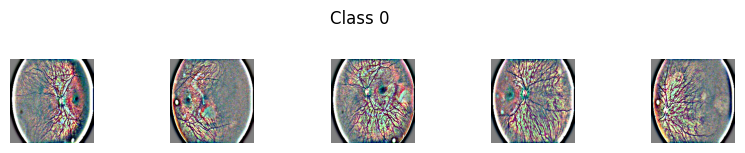

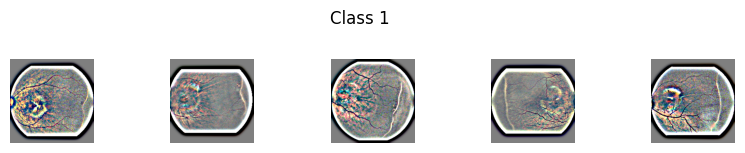

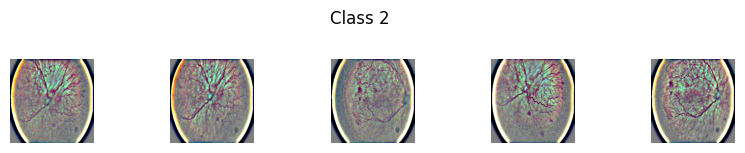

[Fold 0] Ep 1: 100%|██████████| 282/282 [01:22<00:00,  3.44it/s]


[Fold 0][Ep 1] Train=0.521 Val=0.280 Acc=0.860 F1=0.613 QWK=0.611 PatAcc=0.762 AUC=0.925 ECE=0.099


[Fold 0] Ep 2: 100%|██████████| 282/282 [01:26<00:00,  3.27it/s]


[Fold 0][Ep 2] Train=0.323 Val=0.274 Acc=0.898 F1=0.658 QWK=0.698 PatAcc=0.895 AUC=0.975 ECE=0.041


[Fold 0] Ep 3: 100%|██████████| 282/282 [01:25<00:00,  3.31it/s]


...

Final Train Ep 29: 100%|██████████| 399/399 [01:41<00:00,  3.94it/s]


[Final][Ep 29] Loss=0.1568


Final Train Ep 30: 100%|██████████| 399/399 [01:41<00:00,  3.95it/s]

[Final][Ep 30] Loss=0.1565

Applying temperature scaling...


Optimal temperature: 0.718
 Final temperature: 0.718
 Final model saved.

TRAINING COMPLETE


In [ ]:
# CPU/GPU-FRIENDLY ROP STAGE CLASSIFICATION
# Using cached .pt files (images + masks + clinical data)
# Ensemble: MaxViT + EfficientNet + Ben Graham + Mask
# Includes MIL, Grad-CAM, ECE, Temp Scaling, metrics, patient aggregation
import os
import argparse
import warnings
import json

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
import timm

import cv2
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import WeightedRandomSampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    cohen_kappa_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)
import hashlib

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 3

DEFAULT_PT_DIR = "/content/drive/MyDrive/ROP/cache_images"
DEFAULT_CSV = "/content/drive/MyDrive/ROP/stage_data_colab.csv"
OUT_DIR = "/content/drive/MyDrive/ROP/results"

def tensor_hash(t):
    return hashlib.md5(t.cpu().numpy().tobytes()).hexdigest()

# --------------------------
# Rotations
# --------------------------
def random_rotate(img):
    angle = np.random.uniform(-15, 15)  # degrees
    return TF.rotate(img, angle)

def color_jitter(img):
    factor = np.random.uniform(0.8, 1.2)
    img = img * factor
    return torch.clamp(img, 0.0, 1.0)


def gaussian_noise(img, mean=0.0, std=0.01):
    noise = torch.randn_like(img) * std
    img = img + noise
    return torch.clamp(img, 0.0, 1.0)


def horizontal_flip(img):
    return img.flip(-1) if img.dim() == 3 else img

# CLAHE (Contrast Limited Adaptive Histogram Equalization)

def apply_clahe(img):
    img_np = img[:3].cpu().numpy().transpose(1,2,0)
    img_np = (img_np * 255).astype(np.uint8)

    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    lab_planes = list(cv2.split(lab))

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab_planes[0] = clahe.apply(lab_planes[0])

    lab = cv2.merge(lab_planes)
    img_np = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    img_np = img_np.astype(np.float32) / 255.0

    img_new = img.clone()
    img_new[:3] = torch.tensor(img_np.transpose(2,0,1), device=img.device)

    return img_new

def random_gamma(img):
    gamma = np.random.uniform(0.8, 1.2)
    return torch.clamp(img ** gamma, 0, 1)

def remap_stage(stage):
    # Maps any stage >= 2 to 2 (Normal=0, Mild=1, Severe+=2)
    return min(int(stage), 2)

def to_ordinal(labels, num_classes):
    # Converts label 1 to [1, 0], label 2 to [1, 1], label 0 to [0, 0]
    out = torch.zeros((labels.size(0), num_classes - 1), device=labels.device)
    for i in range(labels.size(0)):
        out[i, :labels[i]] = 1
    return out
# ========================
# Seed for reproducibility
# ========================
def set_seed(seed=42):
    import random
    import numpy as np
    import torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# =========================
# Dataset using cached .pt files
# =========================
class ROPDatasetPT(Dataset):
    def __init__(self, pt_paths, augment=False):
        self.pt_paths = pt_paths
        self.augment = augment

    def __len__(self):
        return len(self.pt_paths)

    def __getitem__(self, idx):
        # -------------------------
        # Load cached .pt
        # -------------------------
        data = torch.load(self.pt_paths[idx], map_location="cpu")

        # -------------------------
        # Image
        # -------------------------
        img = data["img"].float()

        # Resize if needed
        if img.shape[1:] != (224, 224):
            img = F.interpolate(
                img.unsqueeze(0),
                (224, 224),
                mode='bilinear',
                align_corners=False
            ).squeeze(0)

        # Ensure 4 channels (RGB + mask)
        if img.shape[0] == 3:
            img = torch.cat([img, torch.zeros(1, 224, 224)], dim=0)

        # --- DOUBLE ABLATION: ZERO OUT THE MASK CHANNEL ---
        # If the image has 4 channels, we set the 4th one (index 3) to zero
        #if img.shape[0] == 4:
        #    img[3, :, :] = 0.0
        #elif img.shape[0] == 3:
            # If it's only 3 channels, we still pad it to 4 with zeros
            # so the model architecture (which expects 4) doesn't crash.
        #   img = torch.cat([img, torch.zeros(1, 224, 224)], dim=0)

        # -------------------------
        # AUGMENTATION (TRAIN ONLY)
        # -------------------------
        if self.augment:

            # ---- CLAHE (low probability, improves vessels) ----
            if np.random.rand() < 0.2:
                img = apply_clahe(img)

            # ---- Horizontal flip ----
            if np.random.rand() < 0.5:
                img = horizontal_flip(img)

            # ---- Rotation (small angles only) ----
            if np.random.rand() < 0.5:
                img = random_rotate(img)

            # ---- Brightness jitter ----
            if np.random.rand() < 0.4:
                img = color_jitter(img)

            # ---- Gaussian noise ----
            if np.random.rand() < 0.3:
                img = gaussian_noise(img, std=0.02)

            if np.random.rand() < 0.3:
              img = random_gamma(img)


        # -------------------------
        # Clinical Data
        # -------------------------
        ga = np.clip(data.get("ga", 30), 22, 40)
        bw = np.clip(data.get("bw", 1200), 400, 2500)

        clinical = torch.tensor([
            (ga - 22) / 18,
            (bw - 400) / 2100
        ], dtype=torch.float32)

        #clinical = torch.zeros(2, dtype=torch.float32)

        # -------------------------
        # Label → Ordinal
        # -------------------------
        raw_label = int(data["label"])
        target = to_ordinal(
            torch.tensor([raw_label]),
            NUM_CLASSES
        ).squeeze(0)

        return img, clinical, target, str(data["patient_id"])

# =========================
# Ensemble Model
# =========================
class ROPNet(nn.Module):
    def __init__(self):
        super().__init__()

        # =========================
        # Backbones (feature extractors)
        # =========================
        self.backbone1 = timm.create_model(
            "convnext_tiny",
            pretrained=True,
            features_only=True,
            in_chans=4
        )

        self.backbone2 = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            features_only=True,
            in_chans=4
        )

        # ---- infer feature dims safely ----
        with torch.no_grad():
            dummy = torch.randn(1, 4, 224, 224)
            f1_ch = self.backbone1(dummy)[-1].shape[1]
            f2_ch = self.backbone2(dummy)[-1].shape[1]

        # =========================
        # Projection heads
        # =========================
        self.conv_head1 = nn.Conv2d(f1_ch, 256, kernel_size=1)
        self.conv_head2 = nn.Conv2d(f2_ch, 256, kernel_size=1)

        # =========================
        # Attention modules
        # =========================
        self.attn1 = nn.Sequential(
            nn.Conv2d(256, 128, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 1, 1)
        )

        self.attn2 = nn.Sequential(
            nn.Conv2d(256, 128, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 1, 1)
        )

        # =========================
        # Clinical branch
        # =========================
        self.clinical_fc = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2)
        )

        # =========================
        # Normalization (IMPORTANT FIX)
        # =========================
        self.norm_img1 = nn.LayerNorm(256)
        self.norm_img2 = nn.LayerNorm(256)
        self.norm_clin = nn.LayerNorm(64)

        # =========================
        # Fusion head
        # =========================
        self.dropout = nn.Dropout(0.3)

        self.ordinal_head = nn.Linear(256 + 256 + 64, NUM_CLASSES - 1)

    # =========================
    # Stable attention pooling
    # =========================
    def attention_pool(self, f, attn_layer):
        """
        f: (B, C, H, W)
        """
        attn = attn_layer(f)  # (B,1,H,W)

        B, _, H, W = attn.shape

        attn = attn.view(B, -1)

        # stable softmax
        attn = attn - attn.max(dim=1, keepdim=True)[0]
        attn = torch.softmax(attn, dim=1)

        attn = attn.view(B, 1, H, W)

        # normalize attention (important fix)
        attn = attn / (attn.sum(dim=(2,3), keepdim=True) + 1e-6)

        f = (f * attn).sum(dim=(2,3))  # weighted pooling

        return f

    # =========================
    # Forward
    # =========================
    def forward(self, x, clinical):

        # -------- Backbone 1 --------
        f1 = self.backbone1(x)[-1]
        f1 = self.conv_head1(f1)
        f1 = self.attention_pool(f1, self.attn1)
        f1 = self.norm_img1(f1)

        # -------- Backbone 2 --------
        f2 = self.backbone2(x)[-1]
        f2 = self.conv_head2(f2)
        f2 = self.attention_pool(f2, self.attn2)
        f2 = self.norm_img2(f2)

        # -------- Clinical --------
        c = self.clinical_fc(clinical)
        c = self.norm_clin(c)

        # -------- Fusion --------
        fused = torch.cat([f1, f2, c], dim=1)
        fused = self.dropout(fused)

        logits_ord = self.ordinal_head(fused)

        return logits_ord
# =========================
# ECE
# =========================
def compute_ece(probs, labels, n_bins=15):
    probs = np.asarray(probs)
    labels = np.asarray(labels)

    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)

    ece = 0.0
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]

        if i == 0:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences > bin_lower) & (confidences <= bin_upper)

        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            acc_in_bin = (predictions[in_bin] == labels[in_bin]).mean()
            conf_in_bin = confidences[in_bin].mean()

            ece += np.abs(acc_in_bin - conf_in_bin) * prop_in_bin

    return float(ece)

# =========================
# Temperature Scaling
# =========================
class TempScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature


    def set_temperature(self, logits_ord, labels):
        optimizer = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)
        labels = labels.long()

        def eval():
            optimizer.zero_grad()

            scaled_logits = logits_ord / self.temperature

            # convert ordinal → class logits (NOT probs)
            probs = ordinal_probs_from_logits(scaled_logits)

            probs = torch.clamp(probs, 1e-6, 1.0)  # stability

            loss = F.nll_loss(torch.log(probs), labels)

            loss.backward()
            return loss

        optimizer.step(eval)

        print(f"Optimal temperature: {self.temperature.item():.3f}")

def apply_temperature_scaling(logits_ord, labels):
    scaler = TempScaler().to(DEVICE)

    logits_ord = logits_ord.detach().to(DEVICE)
    labels = torch.tensor(labels, dtype=torch.long, device=DEVICE)

    scaler.set_temperature(logits_ord, labels)

    scaled_logits = scaler(logits_ord)
    scaled_probs = ordinal_probs_from_logits(scaled_logits)

    return scaled_probs.cpu().numpy(), scaler.temperature.item()

# =========================
# Grad-CAM
# =========================
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.grad = None
        self.act = None

        self.target_layer = model.conv_head1

        self.fwd_handle = self.target_layer.register_forward_hook(self.forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.act = output

    def backward_hook(self, module, grad_in, grad_out):
        self.grad = grad_out[0]

    def generate(self, x, clinical, cls):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        logits_ord = self.model(x, clinical)
        probs = ordinal_probs_from_logits(logits_ord)

        score = probs[:, cls].sum()
        score.backward()

        if self.grad is None or self.act is None:
            raise RuntimeError("GradCAM hooks failed")

        weights = self.grad.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.act).sum(1)

        cam = F.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-6)

        return cam.detach().cpu().numpy()

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()
# ========================
# Duplicate Detection
# ========================
def check_duplicates(train_paths, val_paths):
    print("\n[CHECK] Duplicate image detection...")

    train_hashes = {}
    val_hashes = {}

    # hash train
    for p in train_paths:
        data = torch.load(p, map_location="cpu")
        h = tensor_hash(data["img"])
        train_hashes[h] = p

    # check val against train
    duplicates = []
    for p in val_paths:
        data = torch.load(p, map_location="cpu")
        h = tensor_hash(data["img"])

        if h in train_hashes:
            duplicates.append((p, train_hashes[h]))

    print(f"Duplicates found: {len(duplicates)}")

    if len(duplicates) > 0:
        print("Example duplicate:")
        print(duplicates[0])
# =========================
# Aggregate patient-level metrics
# =========================
def aggregate_patient_metrics(df_val, stage_probs):
    """
    df_val: validation dataframe (one row per image)
    stage_probs: np.array or list of shape (N_images, n_classes)
    """

    df_val = df_val.copy()

    # Attach image-level predictions safely
    df_val["stage_pred_prob"] = list(stage_probs)
    df_val["stage_pred"] = df_val["stage_pred_prob"].apply(np.argmax)

    # --- Aggregate per patient ---
    patient_preds = []
    patient_gts = []

    for pid, g in df_val.groupby("patient_id"):
        probs = np.stack(g["stage_pred_prob"].values)  # (n_imgs, n_classes)

        # Mean probability aggregation
        mean_prob = probs.mean(axis=0)

        patient_preds.append(np.argmax(mean_prob))
        patient_gts.append(g["label"].iloc[0])

    patient_acc = accuracy_score(patient_gts, patient_preds)
    return patient_acc

def patient_level_auc(df_val, stage_probs, num_classes=NUM_CLASSES):

    stage_probs = np.asarray(stage_probs)

    df_val = df_val.copy()
    df_val["probs"] = list(stage_probs)

    patient_probs, patient_labels = [], []

    for pid, g in df_val.groupby("patient_id"):
        probs = np.stack(g["probs"].values)
        mean_prob = probs.mean(axis=0)

        patient_probs.append(mean_prob)
        patient_labels.append(g["label"].iloc[0])

    patient_probs = np.stack(patient_probs)
    patient_labels = np.array(patient_labels)

    unique_classes = np.unique(patient_labels)

    if len(unique_classes) < 2:
        print("[WARNING] AUC skipped: only one class present")
        return np.nan

    try:
        return roc_auc_score(
            patient_labels,
            patient_probs,
            multi_class="ovr",
            average="macro"
        )
    except Exception as e:
        print("AUC error:", e)
        return np.nan
# =========================
# Plot metrics
# =========================
def plot_best_metrics(history, best_epoch, out_dir, fold):
    plt.figure(figsize=(10,6))
    metrics = ["train_loss","val_loss","img_acc","f1","qwk","ece"]
    colors = ["blue","red","green","orange","purple","brown"]
    for m,c in zip(metrics,colors):
        plt.plot([best_epoch],
         [history[m][best_epoch - 1]],
         "o", label=m, color=c)
    plt.title(f"Fold {fold} - Best Epoch Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.ylim(0, max(max(history[m]) for m in metrics)*1.1)
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(out_dir,f"fold{fold}_metrics_best.png"))
    plt.close()

# =========================
# Patient-level thresholding for critical stages
# =========================
def patient_sensitivity_flags(df_val, stage_probs, thresholds, critical_stages=[2]):

    df_val = df_val.copy()
    stage_probs = np.asarray(stage_probs)

    if len(df_val) != len(stage_probs):
        raise ValueError("Mismatch between df_val and stage_probs")

    df_val["probs"] = list(stage_probs)

    patient_flags = []

    for pid, g in df_val.groupby("patient_id"):
        probs = np.stack(g["probs"].values)

        flag = 0

        for s in critical_stages:
            thr = thresholds.get(s, 0.5)

            if (probs[:, s] >= thr).any():
                flag = 1
                break

        patient_flags.append({
            "patient_id": pid,
            "gt_stage": g["label"].iloc[0],
            "flag_critical": flag
        })

    return pd.DataFrame(patient_flags)
# =========================
# Threshold Tuning for Sensitivity
# =========================
def sensitivity_thresholds(y_true, y_probs, target_sens=0.95, critical_stages=[2]):

    thresholds = {}

    for stage in critical_stages:

        y_bin = (y_true >= stage).astype(int)

        fpr, tpr, ths = roc_curve(y_bin, y_probs[:, stage])

        # avoid empty / edge case
        if len(ths) == 0:
            thresholds[stage] = 0.5
            continue

        # closest to target sensitivity
        idx = np.argmin(np.abs(tpr - target_sens))

        thresholds[stage] = ths[idx]

    return thresholds

# =========================
# Confusion Matrix Plot
# =========================
def plot_confusion(y_true, y_pred, classes, out_path):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.savefig(out_path)
    plt.close()
# =========================
# Loss (SIMPLIFIED)
# =========================
def ordinal_probs_from_logits(logits):
    cumulative = torch.sigmoid(logits)

    # enforce monotonic decreasing
    cumulative = torch.cummin(cumulative, dim=1)[0]

    B, K1 = cumulative.shape
    probs = torch.zeros(B, K1 + 1, device=logits.device)

    probs[:, 0] = 1 - cumulative[:, 0]

    for k in range(1, K1):
        probs[:, k] = cumulative[:, k-1] - cumulative[:, k]

    probs[:, -1] = cumulative[:, -1]

    return torch.clamp(probs, 1e-6, 1.0)

# ========================
# Plot random samples per class (for sanity check)
# ========================
def plot_random_samples(pt_paths, num_per_class=5):

    class_samples = {0: [], 1: [], 2: []}

    for p in pt_paths:
        data = torch.load(p, map_location="cpu")
        label = int(data["label"])

        if len(class_samples[label]) < num_per_class:
            class_samples[label].append(data["img"][:3])  # RGB only

        if all(len(v) >= num_per_class for v in class_samples.values()):
            break

    for cls, imgs in class_samples.items():
        plt.figure(figsize=(10, 5))
        for i, img in enumerate(imgs):
            plt.subplot(4, 5, i+1)
            img_np = img.numpy().transpose(1,2,0)
            plt.imshow(img_np)
            plt.axis("off")
        plt.suptitle(f"Class {cls}")
        plt.show()
# =================
# Train
# =================
def filter_paths(df_subset, path_to_pid):
    allowed_ids = set(df_subset["patient_id"].astype(str))

    return [
        p for p in path_to_pid.keys()
        if path_to_pid[p] in allowed_ids
    ]

def train_fold(df, pt_dir, fold, args, path_to_pid, class_weights=None, patience=5):

    out = os.path.join(args.out_dir, f"fold_{fold}")
    os.makedirs(out, exist_ok=True)

    df_train = df[df["fold"] != fold].copy()
    df_val   = df[df["fold"] == fold].copy()

    train_paths = filter_paths(df_train, path_to_pid)
    val_paths   = filter_paths(df_val, path_to_pid)

    check_duplicates(train_paths, val_paths)

    # -------------------------
    # SAMPLER
    # -------------------------
    train_labels = np.array([
        df[df["patient_id"] == path_to_pid[p]]["label"].values[0]
        for p in train_paths
    ])
    class_count = np.bincount(train_labels, minlength=NUM_CLASSES)

    weights = 1.0 / (class_count + 1e-6)
    sample_weights = weights[train_labels]

    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    # -------------------------
    # LOADERS
    # -------------------------
    train_loader = DataLoader(
        ROPDatasetPT(train_paths, augment=True),
        batch_size=args.batch_size,
        sampler=sampler,
        num_workers=4,
        pin_memory=True
    )

    val_loader = DataLoader(
        ROPDatasetPT(val_paths, augment=False),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # -------------------------
    # MODEL
    # -------------------------
    model = ROPNet().to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=0.05)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=args.lr,
        steps_per_epoch=len(train_loader),
        epochs=args.epochs
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    # -------------------------
    # LOSS + DECODER
    # -------------------------
    def compute_loss(logits, targets, weights=None, smoothing=0.1):
        # Smooth targets: 1 -> 0.95, 0 -> 0.05
        targets = targets.float() * (1 - smoothing) + 0.5 * smoothing

        loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        if weights is not None:
            true_ints = targets.sum(dim=1).round().long() # round because of smoothing
            true_ints = torch.clamp(true_ints, 0, NUM_CLASSES - 1)
            batch_weights = weights[true_ints].unsqueeze(1)
            loss = loss * batch_weights

        return loss.mean()

    def decode(logits):
        probs = ordinal_probs_from_logits(logits)
        preds = probs.argmax(dim=1)
        return preds, probs

    # -------------------------
    # TRACKING
    # -------------------------
    best_qwk = -1
    best_epoch = 0
    no_improve = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "img_acc": [],
        "f1": [],
        "qwk": [],
        "ece": [],
        "pat_acc": [],
        "pat_auc": []
    }
    for f in range(args.folds):
        train_patients = set(df[df.fold != f]['patient_id'])
        val_patients = set(df[df.fold == f]['patient_id'])
        overlap = train_patients.intersection(val_patients)
        print(f"Fold {f} Patient Overlap: {len(overlap)}")

    # =========================
    # TRAIN LOOP
    # =========================
    for epoch in range(1, args.epochs + 1):

        if fold == 0 and epoch == 1:
            print("\n[DEBUG] Visual inspection...")
            plot_random_samples(train_paths)

        # ========= TRAIN =========
        model.train()
        train_loss = 0

        for imgs, clin, targets, _ in tqdm(train_loader, desc=f"[Fold {fold}] Ep {epoch}"):

            imgs = imgs.to(DEVICE)
            clin = clin.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = model(imgs, clin)
                loss = compute_loss(logits, targets)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ========= VALIDATION =========
        model.eval()

        val_loss = 0
        all_preds, all_probs, all_true, all_pids = [], [], [], []

        with torch.no_grad():
            for batch_idx, (imgs, clin, targets, pids) in enumerate(val_loader):

                imgs = imgs.to(DEVICE)
                clin = clin.to(DEVICE)
                targets = targets.to(DEVICE)

                logits = model(imgs, clin)

                # Compute loss using the ordinal targets
                loss = compute_loss(logits, targets, class_weights)
                val_loss += loss.item()

                # Get class predictions and probability distributions
                # Ensure your decode function uses ordinal_probs_from_logits
                probs = ordinal_probs_from_logits(logits)
                preds = probs.argmax(dim=1)

                all_preds.append(preds.cpu().numpy())
                all_probs.append(probs.cpu().numpy())

                # FIX: Convert ordinal vector [1, 1, 0] back to integer class 2
                # We sum the 1s across the last dimension
                true_ints = targets.sum(dim=1).long()
                all_true.append(targets.sum(dim=1).long().cpu().numpy())

                all_pids.extend(pids)

        val_loss /= len(val_loader)

        y_pred = np.concatenate(all_preds)
        y_true = np.concatenate(all_true)
        y_prob = np.concatenate(all_probs)

        # ================= METRICS =================
        img_acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="macro")
        qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        ece_val = compute_ece(y_prob, y_true)

        df_val_images = pd.DataFrame({
            "patient_id": all_pids,
            "label": y_true
        })

        pat_acc = aggregate_patient_metrics(df_val_images, y_prob)
        pat_auc = patient_level_auc(df_val_images, y_prob)

        # store history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["img_acc"].append(img_acc)
        history["f1"].append(f1)
        history["qwk"].append(qwk)
        history["ece"].append(ece_val)
        history["pat_acc"].append(pat_acc)
        history["pat_auc"].append(pat_auc)

        print(f"[Fold {fold}][Ep {epoch}] "
              f"Train={train_loss:.3f} Val={val_loss:.3f} "
              f"Acc={img_acc:.3f} F1={f1:.3f} QWK={qwk:.3f} "
              f"PatAcc={pat_acc:.3f} AUC={pat_auc:.3f} ECE={ece_val:.3f}")

        # ================= EARLY STOP =================
        if qwk > best_qwk:
            best_qwk = qwk
            best_epoch = epoch
            no_improve = 0

            torch.save(model.state_dict(), os.path.join(out, "best.pt"))

            best_metrics = {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "img_acc": img_acc,
                "f1": f1,
                "qwk": qwk,
                "ece": ece_val,
                "pat_acc": pat_acc,
                "pat_auc": pat_auc
            }

        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # ================= SAVE HISTORY =================
    with open(os.path.join(out, "history.json"), "w") as f:
        json.dump(history, f, indent=4)

    # ================= SAVE BEST METRICS =================
    with open(os.path.join(out, "metrics_best.json"), "w") as f:
        json.dump(best_metrics, f, indent=4)

    # ================= SAVE LAST METRICS =================
    last_metrics = {k: history[k][-1] for k in history}
    with open(os.path.join(out, "metrics_last.json"), "w") as f:
        json.dump(last_metrics, f, indent=4)

    # ================= SAVE CSV (FOR REPORT TABLES) =================
    df_hist = pd.DataFrame(history)
    df_hist["epoch"] = np.arange(1, len(df_hist)+1)
    df_hist.to_csv(os.path.join(out, "metrics.csv"), index=False)

    print(f"\n Best Epoch: {best_epoch} | Best QWK: {best_qwk:.4f}")

    # ================= FINAL PASS =================
    model.load_state_dict(torch.load(os.path.join(out, "best.pt")))
    model.eval()

    stage_probs, stage_true, preds_all, stage_pids = [], [], [], []

    with torch.no_grad():
        for imgs, clin, targets, pids in val_loader:
            imgs, clin = imgs.to(DEVICE), clin.to(DEVICE)

            logits = model(imgs, clin)
            preds, probs = decode(logits)

            stage_probs.append(probs.cpu().numpy())
            stage_true.append(targets.sum(dim=1).long().cpu().numpy())
            preds_all.append(preds.cpu().numpy())
            stage_pids.extend(pids)

    stage_probs = np.concatenate(stage_probs)
    stage_true = np.concatenate(stage_true)
    preds = np.concatenate(preds_all)

    # =========================
    # SENSITIVITY-BASED THRESHOLDS (Stage 2 focus)
    # =========================
    thresholds = sensitivity_thresholds(
        stage_true,
        stage_probs,
        target_sens=0.95,
        critical_stages=[2]
    )

    print("Sensitivity thresholds:", thresholds)

    df_val_images = pd.DataFrame({
        "patient_id": stage_pids,
        "label": stage_true
    })

    df_flags = patient_sensitivity_flags(
        df_val_images,
        stage_probs,
        thresholds,
        critical_stages=[2]
    )

    df_flags.to_csv(os.path.join(out, "patient_flags.csv"), index=False)
    # ================= PLOTS =================
    plot_confusion(stage_true, preds, list(range(NUM_CLASSES)),
                   os.path.join(out, "confusion_best.png"))

    for s in range(NUM_CLASSES):
        y_bin = (stage_true == s).astype(int)

        fpr, tpr, _ = roc_curve(y_bin, stage_probs[:, s])
        if len(np.unique(y_bin)) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_bin, stage_probs[:, s])

        precision, recall, _ = precision_recall_curve(y_bin, stage_probs[:, s])

        plt.figure()
        plt.plot(fpr, tpr)
        plt.savefig(os.path.join(out, f"roc_stage{s}.png"))
        plt.close()

        plt.figure()
        plt.plot(recall, precision)
        plt.savefig(os.path.join(out, f"pr_stage{s}.png"))
        plt.close()

    # ================= GRAD-CAM =================
    gradcam = GradCAM(model)
    gradcam_dir = os.path.join(out, "gradcam")
    os.makedirs(gradcam_dir, exist_ok=True)

    mis_idx = np.where(preds != stage_true)[0][:5]

    for idx in mis_idx:
        img, clin, label, pid = val_loader.dataset[idx]

        img = img.unsqueeze(0).to(DEVICE)
        clin = clin.unsqueeze(0).to(DEVICE)

        cam = gradcam.generate(img, clin, preds[idx])[0]

        img_np = img[0][:3].cpu().numpy().transpose(1,2,0)
        img_np = (img_np - img_np.min()) / (img_np.max() + 1e-6)

        # Resize
        cam = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

        # =========================
        # HARD RETINA MASK (circle)
        # =========================
        h, w = cam.shape
        y, x_grid = np.ogrid[:h, :w]
        center = (h // 2, w // 2)
        radius = min(center) * 0.95

        hard_mask = ((x_grid - center[1])**2 + (y - center[0])**2 <= radius**2).astype(np.float32)

        # =========================
        # SOFT MASK (image-based fallback)
        # =========================
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        _, soft_mask = cv2.threshold(gray, 0.05, 1, cv2.THRESH_BINARY)
        soft_mask = cv2.GaussianBlur(soft_mask.astype(np.float32), (31,31), 0)
        soft_mask = soft_mask / (soft_mask.max() + 1e-6)

        # =========================
        # COMBINE MASKS
        # =========================
        final_mask = hard_mask * soft_mask

        cam = cam * final_mask

        # =========================
        # SMOOTH CAM (CRITICAL)
        # =========================
        cam = cv2.medianBlur((cam*255).astype(np.uint8), 9) / 255.0
        cam = cv2.GaussianBlur(cam, (21,21), 0)

        # =========================
        # NORMALIZE AGAIN
        # =========================
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-6)

        # enforce mask again
        cam = cam * final_mask

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        overlay = 0.6 * img_np + 0.4 * (heatmap / 255.0)
        overlay = np.clip(overlay, 0, 1)

        plt.imshow(overlay)
        plt.title(f"GT:{label.argmax().item()} Pred:{preds[idx]}")
        plt.axis("off")
        plt.savefig(os.path.join(gradcam_dir, f"{pid}_{idx}.png"))
        plt.close()

    gradcam.remove_hooks()

def final_training(df, args,path_to_pid, class_weights= None):
    print("\n=== FINAL TRAINING ON FULL DATASET ===")

    model = ROPNet().to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=args.epochs
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    all_paths = filter_paths(df, path_to_pid)

    train_loader = DataLoader(
        ROPDatasetPT(all_paths, augment=True),
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    calib_loader = DataLoader(
        ROPDatasetPT(all_paths, augment=False),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # =========================
    # LOSS
    # =========================
    def compute_loss(logits, targets, weights=None, smoothing=0.1):
        # Smooth targets: 1 -> 0.95, 0 -> 0.05
        targets = targets.float() * (1 - smoothing) + 0.5 * smoothing

        loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        if weights is not None:
            true_ints = targets.sum(dim=1).round().long() # round because of smoothing
            true_ints = torch.clamp(true_ints, 0, NUM_CLASSES - 1)
            batch_weights = weights[true_ints].unsqueeze(1)
            loss = loss * batch_weights

        return loss.mean()

    model.train()

    for epoch in range(1, args.epochs + 1):
        epoch_loss = 0.0

        for imgs, clin, stage, _ in tqdm(train_loader, desc=f"Final Train Ep {epoch}"):

            imgs = imgs.to(DEVICE)
            clin = clin.to(DEVICE)
            stage = stage.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = model(imgs, clin)
                loss = compute_loss(logits, stage, class_weights)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

        scheduler.step()

        print(f"[Final][Ep {epoch}] Loss={epoch_loss / len(train_loader):.4f}")

    # =========================
    # TEMPERATURE SCALING
    # =========================
    print("\nApplying temperature scaling...")

    model.eval()

    logits_all, labels_all = [], []

    with torch.no_grad():
        for imgs, clin, stage, _ in calib_loader:

            imgs = imgs.to(DEVICE)
            clin = clin.to(DEVICE)

            logits = model(imgs, clin)

            logits_all.append(logits.cpu())

            # ordinal → class index
            labels_all.append(stage.sum(dim=1).long().cpu())

    logits_all = torch.cat(logits_all).to(DEVICE)
    labels_all = torch.cat(labels_all).to(DEVICE)

    scaler_temp = TempScaler().to(DEVICE)
    scaler_temp.set_temperature(logits_all, labels_all)

    torch.save({
        "model": model.state_dict(),
        "temperature": scaler_temp.temperature.item()
    }, os.path.join(args.out_dir, "final_stage_model.pt"))

    print(f" Final temperature: {scaler_temp.temperature.item():.3f}")
    print(" Final model saved.")
# =========================
# CONFIG (GLOBAL DEFAULTS)
# ========================
class Config:
    def __init__(self):
        self.pt_dir = "/content/drive/MyDrive/ROP/cache_images"
        self.csv_file = "/content/drive/MyDrive/ROP/stage_data_colab.csv"
        self.epochs = 30
        self.batch_size = 16
        self.lr = 5e-5
        self.out_dir = "/content/drive/MyDrive/ROP/results"

# =========================
# MAIN
# =========================
def main():

    # -------------------------
    # Mount Google Drive (Colab)
    # -------------------------
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)
    except Exception:
        print("Not running in Colab or Drive already mounted.")

    set_seed(42)

    parser = argparse.ArgumentParser()
    cfg = Config()

    parser.add_argument("--shuffle_labels", action="store_true")
    parser.add_argument("--folds", type=int, default=3)
    parser.add_argument("--pt_dir", type=str, default=cfg.pt_dir)
    parser.add_argument("--csv_file", type=str, default=cfg.csv_file)
    parser.add_argument("--epochs", type=int, default=cfg.epochs)
    parser.add_argument("--batch_size", type=int, default=cfg.batch_size)
    parser.add_argument("--lr", type=float, default=cfg.lr)
    parser.add_argument("--out_dir", type=str, default=cfg.out_dir)

    args, _ = parser.parse_known_args()
    os.makedirs(args.out_dir, exist_ok=True)

    print("\n=========================")
    print("ROP TRAINING STARTED")
    print("=========================\n")

    # =========================
    # LOAD CSV
    # =========================
    df = pd.read_csv(args.csv_file).dropna()

    df["patient_id"] = df["patient_id"].astype(str).str.strip()
    df["label"] = df["label"].apply(remap_stage)

    print(f"Loaded {len(df)} samples")

    # =========================
    # SANITY CHECK
    # =========================
    if args.shuffle_labels:
        print("\n[WARNING] Shuffling labels for sanity check...")
        df["label"] = np.random.permutation(df["label"].values)

    # =========================
    # LOAD PT FILES (CACHE SAFE)
    # =========================
    cache_file = os.path.join(args.out_dir, "pt_cache_paths.pt")

    if os.path.exists(cache_file):
        print("\n[CACHE] Loading paths...")
        all_paths = torch.load(cache_file)
    else:
        all_paths = [
            os.path.join(args.pt_dir, f)
            for f in os.listdir(args.pt_dir)
            if f.endswith(".pt") and "index" not in f.lower()
        ]
        torch.save(all_paths, cache_file)

    print(f"[INFO] Total images: {len(all_paths)}")

    # =========================
    # BUILD PATH → PATIENT MAP
    # =========================
    path_to_pid = {}
    valid_paths = []

    print("\n[INFO] Mapping patient IDs...")

    for p in tqdm(all_paths):
        try:
            data = torch.load(p, map_location="cpu")
            pid = str(data["patient_id"]).strip()
            path_to_pid[p] = pid
            valid_paths.append(p)
        except:
            continue

    all_paths = valid_paths
    print(f"[INFO] Valid images: {len(all_paths)}")

    # =========================
    # PATIENT-LEVEL SPLIT
    # =========================
    patient_df = df[['patient_id', 'label']].drop_duplicates()

    skf = StratifiedKFold(n_splits=args.folds, shuffle=True, random_state=42)

    patient_df["fold"] = -1

    for fold, (_, val_idx) in enumerate(
        skf.split(patient_df["patient_id"], patient_df["label"])
    ):
        val_pids = patient_df.iloc[val_idx]["patient_id"].values
        patient_df.loc[patient_df["patient_id"].isin(val_pids), "fold"] = fold

    # attach fold back to image dataframe
    df = df.merge(patient_df[['patient_id', 'fold']], on="patient_id", how="left")
    # =========================
    # LEAKAGE CHECK
    # =========================
    for f in range(args.folds):
        train_pids = set(df[df.fold != f]["patient_id"])
        val_pids = set(df[df.fold == f]["patient_id"])

        overlap = train_pids & val_pids
        if overlap:
            raise ValueError(f"[LEAKAGE] Fold {f}: {len(overlap)} patients overlap!")

    print("No patient-level leakage detected")

    # =========================
    # CROSS VALIDATION
    # =========================
    for f in range(args.folds):

        print(f"\n====================")
        print(f"FOLD {f} START")
        print(f"====================")

        train_df = df[df.fold != f]
        val_df = df[df.fold == f]

        train_pids = set(train_df["patient_id"])
        val_pids = set(val_df["patient_id"])

        train_paths = [p for p in all_paths if path_to_pid[p] in train_pids]
        val_paths = [p for p in all_paths if path_to_pid[p] in val_pids]

        print(f"Train images: {len(train_paths)} | Val images: {len(val_paths)}")

        # =========================
        # CLASS WEIGHTS (STABLE)
        # =========================
        class_counts = (
            train_df["label"]
            .value_counts()
            .sort_index()
            .reindex(range(NUM_CLASSES), fill_value=0)
            .values
        )

        weights = 1.0 / np.sqrt(class_counts + 1e-6)
        weights = (weights / weights.sum()) * NUM_CLASSES

        class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

        print(f"Class counts: {class_counts}")
        print(f"Class weights: {weights}")

        try:
            train_fold(df, args.pt_dir, f, args, path_to_pid, class_weights)
        except Exception as e:
            print(f"[ERROR] Fold {f} failed: {e}")
            continue

    # =========================
    # FINAL TRAINING
    # =========================
    print("\n=========================")
    print("FINAL TRAINING (FULL DATA)")
    print("=========================\n")

    class_counts = (
        df["label"]
        .value_counts()
        .sort_index()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .values
    )

    weights = 1.0 / np.sqrt(class_counts + 1e-6)
    weights = (weights / weights.sum()) * NUM_CLASSES

    class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

    print(f"Final class weights: {weights}")

    args.all_paths = all_paths

    final_training(df, args,path_to_pid, class_weights)

    print("\nTRAINING COMPLETE")
if __name__ == "__main__":
    main()

In [4]:
# ============================================================
# ROP STAGE CLASSIFICATION  — FIXED VERSION
# Ensemble: ConvNeXt-Tiny + EfficientNet-B3 + Ben Graham + Vessel Mask
# Fixes applied:
#   [F1]  class_weights now passed to training loss (was silently dropped)
#   [F2]  temperature scaling uses a held-out calibration split (was on train data)
#   [F3]  plt.show() replaced with plt.savefig() (was blocking on servers)
#   [F4]  check_duplicates returns list so caller can log properly
#   [F5]  WeightedRandomSampler uses 1/sqrt(count) to match loss weighting
#   [F6]  compute_loss extracted to module level (was duplicated in 2 functions)
#   [F7]  redundant leakage print loop removed from train_fold()
#   [F8]  bare except replaced with except Exception
#   [F9]  dead ablation comments removed
# ============================================================

import os
import argparse
import warnings
import json
import random
import hashlib

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split

import torchvision.transforms.functional as TF
import timm

import cv2
from tqdm import tqdm

import matplotlib
matplotlib.use("Agg")          # non-interactive backend — safe on all servers
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    cohen_kappa_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 3


# ─────────────────────────────────────────────────────────────────────────────
# REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# ─────────────────────────────────────────────────────────────────────────────
# UTILITIES
# ─────────────────────────────────────────────────────────────────────────────
def tensor_hash(t: torch.Tensor) -> str:
    return hashlib.md5(t.cpu().numpy().tobytes()).hexdigest()


def remap_stage(stage) -> int:
    """Collapse Stages 2-5 → 2  (Normal=0, Mild=1, Severe=2)."""
    return min(int(stage), 2)


def to_ordinal(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    """Convert integer labels to cumulative binary threshold vectors.
    0 → [0,0]   1 → [1,0]   2 → [1,1]
    """
    out = torch.zeros((labels.size(0), num_classes - 1), device=labels.device)
    for i in range(labels.size(0)):
        out[i, :labels[i]] = 1
    return out


def ordinal_probs_from_logits(logits: torch.Tensor) -> torch.Tensor:
    """Decode K-1 ordinal logits → K class probabilities with monotonicity."""
    cumulative = torch.sigmoid(logits)
    cumulative = torch.cummin(cumulative, dim=1)[0]   # enforce P(>=k) non-increasing

    B, K1 = cumulative.shape
    probs  = torch.zeros(B, K1 + 1, device=logits.device)
    probs[:, 0] = 1 - cumulative[:, 0]
    for k in range(1, K1):
        probs[:, k] = cumulative[:, k - 1] - cumulative[:, k]
    probs[:, -1] = cumulative[:, -1]
    return torch.clamp(probs, 1e-6, 1.0)


# ─────────────────────────────────────────────────────────────────────────────
# [F6] MODULE-LEVEL LOSS  (was duplicated inside train_fold and final_training)
# ─────────────────────────────────────────────────────────────────────────────
def compute_loss(
    logits:   torch.Tensor,
    targets:  torch.Tensor,
    weights:  torch.Tensor | None = None,
    smoothing: float = 0.1,
) -> torch.Tensor:
    """
    Ordinal BCE with optional per-sample class weighting and label smoothing.
    smoothing=0.1 → true label 1→0.95, 0→0.05
    """
    targets = targets.float() * (1 - smoothing) + 0.5 * smoothing
    loss    = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

    if weights is not None:
        # Recover integer class from smoothed ordinal vector
        true_ints    = targets.sum(dim=1).round().long()          # [F6] round after smoothing
        true_ints    = torch.clamp(true_ints, 0, NUM_CLASSES - 1)
        batch_weights = weights[true_ints].unsqueeze(1)
        loss          = loss * batch_weights

    return loss.mean()


# ─────────────────────────────────────────────────────────────────────────────
# AUGMENTATION
# ─────────────────────────────────────────────────────────────────────────────
def random_rotate(img: torch.Tensor) -> torch.Tensor:
    return TF.rotate(img, float(np.random.uniform(-15, 15)))

def color_jitter(img: torch.Tensor) -> torch.Tensor:
    return torch.clamp(img * np.random.uniform(0.8, 1.2), 0.0, 1.0)

def gaussian_noise(img: torch.Tensor, std: float = 0.02) -> torch.Tensor:
    return torch.clamp(img + torch.randn_like(img) * std, 0.0, 1.0)

def horizontal_flip(img: torch.Tensor) -> torch.Tensor:
    return img.flip(-1) if img.dim() == 3 else img

def random_gamma(img: torch.Tensor) -> torch.Tensor:
    return torch.clamp(img ** np.random.uniform(0.8, 1.2), 0.0, 1.0)

def apply_clahe(img: torch.Tensor) -> torch.Tensor:
    """CLAHE in LAB space; operates on a clone — does not mutate input."""
    img_np  = (img[:3].cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
    lab     = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    planes  = list(cv2.split(lab))
    planes[0] = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(planes[0])
    lab     = cv2.merge(planes)
    img_np  = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB).astype(np.float32) / 255.0
    out     = img.clone()
    out[:3] = torch.tensor(img_np.transpose(2, 0, 1), device=img.device)
    return out


# ─────────────────────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────────────────────
class ROPDatasetPT(Dataset):
    def __init__(self, pt_paths: list, augment: bool = False):
        self.pt_paths = pt_paths
        self.augment  = augment

    def __len__(self) -> int:
        return len(self.pt_paths)

    def __getitem__(self, idx: int):
        data = torch.load(self.pt_paths[idx], map_location="cpu")

        img = data["img"].float()

        # Resize if cached at wrong resolution
        if img.shape[1:] != (224, 224):
            img = F.interpolate(
                img.unsqueeze(0), (224, 224),
                mode="bilinear", align_corners=False
            ).squeeze(0)

        # Ensure 4 channels (RGB + vessel mask)
        if img.shape[0] == 3:
            img = torch.cat([img, torch.zeros(1, 224, 224)], dim=0)

        # Augmentation — training only
        if self.augment:
            if np.random.rand() < 0.2:
                img = apply_clahe(img)
            if np.random.rand() < 0.5:
                img = horizontal_flip(img)
            if np.random.rand() < 0.5:
                img = random_rotate(img)
            if np.random.rand() < 0.4:
                img = color_jitter(img)
            if np.random.rand() < 0.3:
                img = gaussian_noise(img)
            if np.random.rand() < 0.3:
                img = random_gamma(img)

        # Clinical features — normalised with fixed physiological bounds
        ga = float(np.clip(data.get("ga", 30), 22, 40))
        bw = float(np.clip(data.get("bw", 1200), 400, 2500))
        clinical = torch.tensor(
            [(ga - 22) / 18.0, (bw - 400) / 2100.0],
            dtype=torch.float32
        )

        # Label → ordinal encoding
        raw_label = int(data["label"])
        target    = to_ordinal(torch.tensor([raw_label]), NUM_CLASSES).squeeze(0)

        return img, clinical, target, str(data["patient_id"])


# ─────────────────────────────────────────────────────────────────────────────
# MODEL: ROPNet
# ─────────────────────────────────────────────────────────────────────────────
class ROPNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone1 = timm.create_model(
            "convnext_tiny", pretrained=True, features_only=True, in_chans=4)
        self.backbone2 = timm.create_model(
            "efficientnet_b3", pretrained=True, features_only=True, in_chans=4)

        with torch.no_grad():
            dummy = torch.randn(1, 4, 224, 224)
            f1_ch = self.backbone1(dummy)[-1].shape[1]
            f2_ch = self.backbone2(dummy)[-1].shape[1]

        self.conv_head1 = nn.Conv2d(f1_ch, 256, kernel_size=1)
        self.conv_head2 = nn.Conv2d(f2_ch, 256, kernel_size=1)

        self.attn1 = nn.Sequential(
            nn.Conv2d(256, 128, 1), nn.ReLU(inplace=True), nn.Conv2d(128, 1, 1))
        self.attn2 = nn.Sequential(
            nn.Conv2d(256, 128, 1), nn.ReLU(inplace=True), nn.Conv2d(128, 1, 1))

        self.clinical_fc = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(inplace=True), nn.Dropout(0.2))

        self.norm_img1 = nn.LayerNorm(256)
        self.norm_img2 = nn.LayerNorm(256)
        self.norm_clin = nn.LayerNorm(64)

        self.dropout      = nn.Dropout(0.3)
        self.ordinal_head = nn.Linear(256 + 256 + 64, NUM_CLASSES - 1)

    def attention_pool(self, f: torch.Tensor, attn_layer: nn.Module) -> torch.Tensor:
        attn = attn_layer(f)
        B, _, H, W = attn.shape
        attn = attn.view(B, -1)
        attn = attn - attn.max(dim=1, keepdim=True)[0]   # numerical stability
        attn = torch.softmax(attn, dim=1).view(B, 1, H, W)
        attn = attn / (attn.sum(dim=(2, 3), keepdim=True) + 1e-6)
        return (f * attn).sum(dim=(2, 3))

    def forward(self, x: torch.Tensor, clinical: torch.Tensor) -> torch.Tensor:
        f1 = self.norm_img1(self.attention_pool(self.conv_head1(self.backbone1(x)[-1]), self.attn1))
        f2 = self.norm_img2(self.attention_pool(self.conv_head2(self.backbone2(x)[-1]), self.attn2))
        c  = self.norm_clin(self.clinical_fc(clinical))
        return self.ordinal_head(self.dropout(torch.cat([f1, f2, c], dim=1)))


# ─────────────────────────────────────────────────────────────────────────────
# TEMPERATURE SCALING
# ─────────────────────────────────────────────────────────────────────────────
class TempScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        return logits / self.temperature

    def set_temperature(self, logits_ord: torch.Tensor, labels: torch.Tensor) -> None:
        optimizer = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)
        labels    = labels.long()

        def closure():
            optimizer.zero_grad()
            probs = torch.clamp(
                ordinal_probs_from_logits(logits_ord / self.temperature), 1e-6, 1.0)
            loss  = F.nll_loss(torch.log(probs), labels)
            loss.backward()
            return loss

        optimizer.step(closure)
        print(f"Optimal temperature: {self.temperature.item():.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# ECE
# ─────────────────────────────────────────────────────────────────────────────
def compute_ece(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    probs, labels   = np.asarray(probs), np.asarray(labels)
    confidences     = probs.max(axis=1)
    predictions     = probs.argmax(axis=1)
    ece             = 0.0
    bins            = np.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        lo, hi   = bins[i], bins[i + 1]
        in_bin   = (confidences >= lo) & (confidences <= hi) if i == 0 else \
                   (confidences > lo)  & (confidences <= hi)
        prop     = in_bin.mean()
        if prop > 0:
            ece += prop * abs(
                (predictions[in_bin] == labels[in_bin]).mean() -
                confidences[in_bin].mean()
            )
    return float(ece)


# ─────────────────────────────────────────────────────────────────────────────
# GRAD-CAM
# ─────────────────────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model: ROPNet):
        self.model = model
        self.grad  = None
        self.act   = None
        self.fwd_handle = model.conv_head1.register_forward_hook(self._fwd)
        self.bwd_handle = model.conv_head1.register_full_backward_hook(self._bwd)

    def _fwd(self, _, __, output):           self.act  = output
    def _bwd(self, _, __, grad_out):         self.grad = grad_out[0]

    def generate(self, x: torch.Tensor, clinical: torch.Tensor, cls: int) -> np.ndarray:
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        probs = ordinal_probs_from_logits(self.model(x, clinical))
        probs[:, cls].sum().backward()

        if self.grad is None or self.act is None:
            raise RuntimeError("GradCAM hooks did not fire.")

        weights = self.grad.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.act).sum(1))
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-6)
        return cam.detach().cpu().numpy()

    def remove_hooks(self) -> None:
        self.fwd_handle.remove()
        self.bwd_handle.remove()


# ─────────────────────────────────────────────────────────────────────────────
# [F4] DUPLICATE DETECTION — now returns list for caller to act on
# ─────────────────────────────────────────────────────────────────────────────
def check_duplicates(train_paths: list, val_paths: list) -> list:
    """
    Hash-based duplicate detection across train/val split.
    Returns list of (val_path, train_path) pairs that are duplicates.
    NOTE: these are within-patient duplicates (same patient, different sessions).
    They do not constitute patient-level leakage but may inflate validation
    estimates slightly.
    """
    print("\n[CHECK] Duplicate image detection...")
    train_hashes = {}
    for p in train_paths:
        try:
            h = tensor_hash(torch.load(p, map_location="cpu")["img"])
            train_hashes[h] = p
        except Exception as e:
            print(f"[WARNING] Could not hash {p}: {e}")

    duplicates = []
    for p in val_paths:
        try:
            h = tensor_hash(torch.load(p, map_location="cpu")["img"])
            if h in train_hashes:
                duplicates.append((p, train_hashes[h]))
        except Exception as e:
            print(f"[WARNING] Could not hash {p}: {e}")

    print(f"Duplicates found: {len(duplicates)}")
    if duplicates:
        print(f"Example: {duplicates[0]}")
        print("[INFO] These are within-fold duplicates (same patient, different sessions).")
        print("[INFO] No patient-level leakage — but may marginally inflate val estimates.")

    return duplicates


# ─────────────────────────────────────────────────────────────────────────────
# PATIENT-LEVEL AGGREGATION
# ─────────────────────────────────────────────────────────────────────────────
def aggregate_patient_metrics(df_val: pd.DataFrame, stage_probs: np.ndarray) -> float:
    df_val = df_val.copy()
    df_val["stage_pred_prob"] = list(stage_probs)
    preds, gts = [], []
    for _, g in df_val.groupby("patient_id"):
        preds.append(np.argmax(np.stack(g["stage_pred_prob"].values).mean(axis=0)))
        gts.append(g["label"].iloc[0])
    return accuracy_score(gts, preds)


def patient_level_auc(df_val: pd.DataFrame, stage_probs: np.ndarray) -> float:
    df_val = df_val.copy()
    df_val["probs"] = list(np.asarray(stage_probs))
    patient_probs, patient_labels = [], []
    for _, g in df_val.groupby("patient_id"):
        patient_probs.append(np.stack(g["probs"].values).mean(axis=0))
        patient_labels.append(g["label"].iloc[0])

    patient_probs  = np.stack(patient_probs)
    patient_labels = np.array(patient_labels)

    if len(np.unique(patient_labels)) < 2:
        print("[WARNING] AUC skipped: only one class present in validation.")
        return np.nan
    try:
        return roc_auc_score(patient_labels, patient_probs,
                             multi_class="ovr", average="macro")
    except Exception as e:
        print(f"AUC error: {e}")
        return np.nan


# ─────────────────────────────────────────────────────────────────────────────
# SENSITIVITY THRESHOLDS (95% recall target on Severe class)
# ─────────────────────────────────────────────────────────────────────────────
def sensitivity_thresholds(
    y_true: np.ndarray,
    y_probs: np.ndarray,
    target_sens: float = 0.95,
    critical_stages: list = [2],
) -> dict:
    thresholds = {}
    for stage in critical_stages:
        y_bin = (y_true >= stage).astype(int)
        _, tpr, ths = roc_curve(y_bin, y_probs[:, stage])
        thresholds[stage] = ths[np.argmin(np.abs(tpr - target_sens))] if len(ths) else 0.5
    return thresholds


def patient_sensitivity_flags(
    df_val: pd.DataFrame,
    stage_probs: np.ndarray,
    thresholds: dict,
    critical_stages: list = [2],
) -> pd.DataFrame:
    df_val      = df_val.copy()
    stage_probs = np.asarray(stage_probs)
    df_val["probs"] = list(stage_probs)
    rows = []
    for pid, g in df_val.groupby("patient_id"):
        probs = np.stack(g["probs"].values)
        flag  = int(any(
            (probs[:, s] >= thresholds.get(s, 0.5)).any()
            for s in critical_stages
        ))
        rows.append({"patient_id": pid, "gt_stage": g["label"].iloc[0], "flag_critical": flag})
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────────────────────────────────────
# PLOTTING HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def plot_confusion(y_true, y_pred, classes, out_path: str) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def plot_roc_pr(stage_true, stage_probs, out_dir: str) -> None:
    for s in range(NUM_CLASSES):
        y_bin = (stage_true == s).astype(int)
        if len(np.unique(y_bin)) < 2:
            continue

        fpr, tpr, _          = roc_curve(y_bin, stage_probs[:, s])
        precision, recall, _ = precision_recall_curve(y_bin, stage_probs[:, s])

        plt.figure()
        plt.plot(fpr, tpr)
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC — Stage {s}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"roc_stage{s}.png"))
        plt.close()

        plt.figure()
        plt.plot(recall, precision)
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"PR — Stage {s}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"pr_stage{s}.png"))
        plt.close()


def plot_random_samples(pt_paths: list, out_dir: str, num_per_class: int = 5) -> None:
    """[F3] Saves sample images to disk instead of calling plt.show()."""
    class_samples: dict = {0: [], 1: [], 2: []}
    for p in pt_paths:
        data  = torch.load(p, map_location="cpu")
        label = int(data["label"])
        if len(class_samples[label]) < num_per_class:
            class_samples[label].append(data["img"][:3])
        if all(len(v) >= num_per_class for v in class_samples.values()):
            break

    for cls, imgs in class_samples.items():
        if not imgs:
            continue
        plt.figure(figsize=(10, 5))
        for i, img in enumerate(imgs):
            plt.subplot(1, num_per_class, i + 1)
            img_np = img.numpy().transpose(1, 2, 0)
            img_np = np.clip(img_np, 0, 1)
            plt.imshow(img_np); plt.axis("off")
        plt.suptitle(f"Class {cls}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"debug_samples_class{cls}.png"))   # [F3]
        plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# HELPER
# ─────────────────────────────────────────────────────────────────────────────
def filter_paths(df_subset: pd.DataFrame, path_to_pid: dict) -> list:
    allowed = set(df_subset["patient_id"].astype(str))
    return [p for p in path_to_pid if path_to_pid[p] in allowed]


# ─────────────────────────────────────────────────────────────────────────────
# GRAD-CAM VISUALISATION (post fold)
# ─────────────────────────────────────────────────────────────────────────────
def visualise_gradcam(model, val_loader, preds, stage_true, out_dir: str) -> None:
    gradcam     = GradCAM(model)
    gradcam_dir = os.path.join(out_dir, "gradcam")
    os.makedirs(gradcam_dir, exist_ok=True)

    mis_idx = np.where(preds != stage_true)[0][:5]

    for idx in mis_idx:
        img, clin, label, pid = val_loader.dataset[idx]
        img  = img.unsqueeze(0).to(DEVICE)
        clin = clin.unsqueeze(0).to(DEVICE)
        cam  = gradcam.generate(img, clin, int(preds[idx]))[0]

        img_np = img[0, :3].cpu().numpy().transpose(1, 2, 0)
        img_np = (img_np - img_np.min()) / (img_np.max() + 1e-6)
        cam    = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

        # Circular hard mask
        h, w   = cam.shape
        y, xg  = np.ogrid[:h, :w]
        cy, cx = h // 2, w // 2
        hard   = ((xg - cx) ** 2 + (y - cy) ** 2 <= (min(cy, cx) * 0.95) ** 2).astype(np.float32)

        # Soft image-based mask
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        _, soft = cv2.threshold(gray, 0.05, 1, cv2.THRESH_BINARY)
        soft = cv2.GaussianBlur(soft.astype(np.float32), (31, 31), 0)
        soft = soft / (soft.max() + 1e-6)

        cam = cv2.GaussianBlur(
            cv2.medianBlur(
                (cam * hard * soft * 255).astype(np.uint8), 9
            ) / 255.0,
            (21, 21), 0
        )
        cam = (cam - cam.min()) / (cam.max() + 1e-6) * hard * soft

        heat    = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB
        )
        overlay = np.clip(0.6 * img_np + 0.4 * heat / 255.0, 0, 1)

        plt.figure()
        plt.imshow(overlay)
        plt.title(f"GT:{label.argmax().item()}  Pred:{int(preds[idx])}")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(gradcam_dir, f"{pid}_{idx}.png"))
        plt.close()

    gradcam.remove_hooks()


# ─────────────────────────────────────────────────────────────────────────────
# TRAIN FOLD
# ─────────────────────────────────────────────────────────────────────────────
def train_fold(
    df: pd.DataFrame,
    pt_dir: str,
    fold: int,
    args,
    path_to_pid: dict,
    class_weights: torch.Tensor | None = None,
    patience: int = 5,
) -> None:

    out = os.path.join(args.out_dir, f"fold_{fold}")
    os.makedirs(out, exist_ok=True)

    train_paths = filter_paths(df[df["fold"] != fold], path_to_pid)
    val_paths   = filter_paths(df[df["fold"] == fold],  path_to_pid)

    # [F4] Duplicate check — log but do not remove (within-fold, not leakage)
    duplicates = check_duplicates(train_paths, val_paths)

    if duplicates:
        dup_val = set([v for v, _ in duplicates])
        before = len(val_paths)
        val_paths = [p for p in val_paths if p not in dup_val]
        print(f"[CLEAN] Removed {before - len(val_paths)} duplicate images from validation")

    # ── Sampler ─────────────────────────────────────────────────────────────
    train_labels = np.array([
        df[df["patient_id"] == path_to_pid[p]]["label"].values[0]
        for p in train_paths
    ])
    class_count = np.bincount(train_labels, minlength=NUM_CLASSES)

    # [F5] Use 1/sqrt to match the loss weighting strategy
    sw = 1.0 / np.sqrt(class_count + 1e-6)
    sw = (sw / sw.sum()) * NUM_CLASSES
    #sampler = WeightedRandomSampler(sw[train_labels], len(train_labels), replacement=True)

    # ── DataLoaders ──────────────────────────────────────────────────────────
    train_loader = DataLoader(
        ROPDatasetPT(train_paths, augment=True),
        batch_size=args.batch_size, #sampler=sampler,
        shuffle=True,
        num_workers=4, pin_memory=True,
    )
    val_loader = DataLoader(
        ROPDatasetPT(val_paths, augment=False),
        batch_size=args.batch_size, shuffle=False,
        num_workers=4, pin_memory=True,
    )

    # ── Model / optimiser ────────────────────────────────────────────────────
    model     = ROPNet().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=args.lr,
        steps_per_epoch=len(train_loader), epochs=args.epochs,
    )
    amp_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    # ── Debug sample visualisation (fold 0, epoch 1 only) ────────────────────
    if fold == 0:
        plot_random_samples(train_paths, out)

    # ── Training loop ────────────────────────────────────────────────────────
    best_qwk, best_epoch, no_improve = -1.0, 0, 0
    best_metrics: dict = {}
    history = {k: [] for k in
               ["train_loss", "val_loss", "img_acc", "f1", "qwk", "ece", "pat_acc", "pat_auc"]}

    for epoch in range(1, args.epochs + 1):

        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for imgs, clin, targets, _ in tqdm(train_loader, desc=f"[Fold {fold}] Ep {epoch}"):
            imgs, clin, targets = imgs.to(DEVICE), clin.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = model(imgs, clin)
                # [F1] Pass class_weights to training loss — was missing before
                loss   = compute_loss(logits, targets, class_weights)

            amp_scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            scheduler.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        all_preds, all_probs, all_true, all_pids = [], [], [], []

        with torch.no_grad():
            for imgs, clin, targets, pids in val_loader:
                imgs, clin, targets = imgs.to(DEVICE), clin.to(DEVICE), targets.to(DEVICE)
                logits = model(imgs, clin)
                val_loss += compute_loss(logits, targets, class_weights).item()

                probs = ordinal_probs_from_logits(logits)
                all_preds.append(probs.argmax(dim=1).cpu().numpy())
                all_probs.append(probs.cpu().numpy())
                all_true.append(targets.sum(dim=1).long().cpu().numpy())
                all_pids.extend(pids)

        val_loss /= len(val_loader)
        y_pred = np.concatenate(all_preds)
        y_true = np.concatenate(all_true)
        y_prob = np.concatenate(all_probs)

        img_acc = accuracy_score(y_true, y_pred)
        f1      = f1_score(y_true, y_pred, average="macro", zero_division=0)
        qwk     = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        ece_val = compute_ece(y_prob, y_true)

        df_val_img = pd.DataFrame({"patient_id": all_pids, "label": y_true})
        pat_acc    = aggregate_patient_metrics(df_val_img, y_prob)
        pat_auc    = patient_level_auc(df_val_img, y_prob)

        for k, v in zip(history, [train_loss, val_loss, img_acc, f1, qwk, ece_val, pat_acc, pat_auc]):
            history[k].append(v)

        print(f"[Fold {fold}][Ep {epoch}] "
              f"Train={train_loss:.3f} Val={val_loss:.3f} "
              f"Acc={img_acc:.3f} F1={f1:.3f} QWK={qwk:.3f} "
              f"PatAcc={pat_acc:.3f} AUC={pat_auc:.3f} ECE={ece_val:.3f}")

        # ── Early stopping on QWK ────────────────────────────────────────────
        if qwk > best_qwk:
            best_qwk, best_epoch, no_improve = qwk, epoch, 0
            torch.save(model.state_dict(), os.path.join(out, "best.pt"))
            best_metrics = dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                                img_acc=img_acc, f1=f1, qwk=qwk, ece=ece_val,
                                pat_acc=pat_acc, pat_auc=pat_auc)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # ── Save artefacts ───────────────────────────────────────────────────────
    for fname, obj in [("history.json", history),
                        ("metrics_best.json", best_metrics),
                        ("metrics_last.json", {k: history[k][-1] for k in history})]:
        with open(os.path.join(out, fname), "w") as fh:
            json.dump(obj, fh, indent=4)

    pd.DataFrame({**history, "epoch": np.arange(1, len(history["qwk"]) + 1)}) \
      .to_csv(os.path.join(out, "metrics.csv"), index=False)

    print(f"\n Best Epoch: {best_epoch} | Best QWK: {best_qwk:.4f}")

    # ── Final evaluation pass with best weights ──────────────────────────────
    model.load_state_dict(torch.load(os.path.join(out, "best.pt")))
    model.eval()

    stage_probs, stage_true, preds_all, stage_pids = [], [], [], []
    with torch.no_grad():
        for imgs, clin, targets, pids in val_loader:
            imgs, clin = imgs.to(DEVICE), clin.to(DEVICE)
            probs = ordinal_probs_from_logits(model(imgs, clin))
            stage_probs.append(probs.cpu().numpy())
            stage_true.append(targets.sum(dim=1).long().cpu().numpy())
            preds_all.append(probs.argmax(dim=1).cpu().numpy())
            stage_pids.extend(pids)

    stage_probs = np.concatenate(stage_probs)
    stage_true  = np.concatenate(stage_true)
    preds       = np.concatenate(preds_all)

    thresholds = sensitivity_thresholds(stage_true, stage_probs, target_sens=0.95)
    print("Sensitivity thresholds:", thresholds)

    df_flags = patient_sensitivity_flags(
        pd.DataFrame({"patient_id": stage_pids, "label": stage_true}),
        stage_probs, thresholds,
    )
    df_flags.to_csv(os.path.join(out, "patient_flags.csv"), index=False)

    plot_confusion(stage_true, preds, list(range(NUM_CLASSES)),
                   os.path.join(out, "confusion_best.png"))
    plot_roc_pr(stage_true, stage_probs, out)
    visualise_gradcam(model, val_loader, preds, stage_true, out)


# ─────────────────────────────────────────────────────────────────────────────
# FINAL TRAINING  (full dataset)
# ─────────────────────────────────────────────────────────────────────────────
def final_training(
    df: pd.DataFrame,
    args,
    path_to_pid: dict,
    class_weights: torch.Tensor | None = None,
) -> None:
    print("\n=== FINAL TRAINING ON FULL DATASET ===")

    all_paths = filter_paths(df, path_to_pid)

    # [F2] LEAKAGE FIX: hold out 15% for calibration BEFORE training begins
    #      Calibration set is never seen during training.
    n_total  = len(all_paths)
    n_calib  = max(1, int(0.15 * n_total))
    n_train  = n_total - n_calib

    rng           = torch.Generator().manual_seed(42)
    # ── Patient-level split (NO LEAKAGE) ─────────────────────────────
    all_patients = df["patient_id"].astype(str).unique()
    rng_np = np.random.RandomState(42)
    rng_np.shuffle(all_patients)

    n_calib_patients = max(1, int(0.15 * len(all_patients)))
    calib_patient_ids = set(all_patients[:n_calib_patients])

    train_paths_final = [
        p for p in all_paths if path_to_pid[p] not in calib_patient_ids
    ]
    calib_paths_final = [
        p for p in all_paths if path_to_pid[p] in calib_patient_ids
    ]

    print(f"Final training: {len(train_paths_final)} images | "
          f"Calibration hold-out: {len(calib_paths_final)} images | "
          f"Patients (calib): {len(calib_patient_ids)}")

    print(f"Final training: {len(train_paths_final)} images | "
          f"Calibration hold-out: {len(calib_paths_final)} images")

    train_loader = DataLoader(
        ROPDatasetPT(train_paths_final, augment=True),
        batch_size=args.batch_size, shuffle=True,
        num_workers=4, pin_memory=True,
    )
    calib_loader = DataLoader(
        ROPDatasetPT(calib_paths_final, augment=False),
        batch_size=args.batch_size, shuffle=False,
        num_workers=4, pin_memory=True,
    )

    model     = ROPNet().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)
    amp_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    model.train()
    for epoch in range(1, args.epochs + 1):
        epoch_loss = 0.0
        for imgs, clin, stage, _ in tqdm(train_loader, desc=f"Final Train Ep {epoch}"):
            imgs, clin, stage = imgs.to(DEVICE), clin.to(DEVICE), stage.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                loss = compute_loss(model(imgs, clin), stage, class_weights)  # [F1]
            amp_scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            epoch_loss += loss.item()
        scheduler.step()
        print(f"[Final][Ep {epoch}] Loss={epoch_loss / len(train_loader):.4f}")

    # ── Temperature scaling on the held-out calibration set ──────────────────
    # [F2] Uses calib_loader (unseen data), NOT the training set
    print("\nApplying temperature scaling on held-out calibration set...")
    model.eval()
    logits_all, labels_all = [], []

    with torch.no_grad():
        for imgs, clin, stage, _ in calib_loader:
            imgs, clin = imgs.to(DEVICE), clin.to(DEVICE)
            logits_all.append(model(imgs, clin).cpu())
            labels_all.append(stage.sum(dim=1).long().cpu())

    logits_all  = torch.cat(logits_all).to(DEVICE)
    labels_all  = torch.cat(labels_all).to(DEVICE)

    temp_scaler = TempScaler().to(DEVICE)
    temp_scaler.set_temperature(logits_all, labels_all)

    # Verify calibration on the held-out set
    with torch.no_grad():
        calib_probs = ordinal_probs_from_logits(
            logits_all / temp_scaler.temperature
        ).cpu().numpy()
    calib_ece = compute_ece(calib_probs, labels_all.cpu().numpy())
    print(f" Calibration ECE (held-out): {calib_ece:.4f}")
    print(f" Final temperature: {temp_scaler.temperature.item():.3f}")

    torch.save(
        {"model": model.state_dict(),
         "temperature": temp_scaler.temperature.item()},
        os.path.join(args.out_dir, "final_stage_model.pt"),
    )
    print(" Final model saved.")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
def main() -> None:
    set_seed(42)

    # ── Colab Drive mount (no-op outside Colab) ───────────────────────────────
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=True)
    except Exception:
        pass

    # ── Argument parsing with Colab-friendly defaults ─────────────────────────
    parser = argparse.ArgumentParser(description="ROP Stage Classification Training")
    parser.add_argument("--shuffle_labels", action="store_true",
                        help="Shuffle labels (sanity check — performance should drop to chance)")
    parser.add_argument("--folds",      type=int,   default=3)
    parser.add_argument("--epochs",     type=int,   default=30)
    parser.add_argument("--batch_size", type=int,   default=16)
    parser.add_argument("--lr",         type=float, default=5e-5)
    parser.add_argument("--pt_dir",     type=str,
                        default="/content/drive/MyDrive/ROP/cache_images")
    parser.add_argument("--csv_file",   type=str,
                        default="/content/drive/MyDrive/ROP/stage_data_colab.csv")
    parser.add_argument("--out_dir",    type=str,
                        default="/content/drive/MyDrive/ROP/results")
    args, _ = parser.parse_known_args()
    os.makedirs(args.out_dir, exist_ok=True)

    print("\n=========================")
    print("ROP TRAINING STARTED")
    print("=========================\n")

    # ── Load and clean CSV ────────────────────────────────────────────────────
    df = pd.read_csv(args.csv_file).dropna()
    df["patient_id"] = df["patient_id"].astype(str).str.strip()
    df["label"]      = df["label"].apply(remap_stage)
    print(f"Loaded {len(df)} samples")

    if args.shuffle_labels:
        print("\n[WARNING] Shuffling labels for sanity check...")
        df["label"] = np.random.permutation(df["label"].values)

    # ── Load cached .pt paths ─────────────────────────────────────────────────
    cache_file = os.path.join(args.out_dir, "pt_cache_paths.pt")
    if os.path.exists(cache_file):
        print("\n[CACHE] Loading paths...")
        all_paths = torch.load(cache_file)
    else:
        all_paths = [
            os.path.join(args.pt_dir, f)
            for f in os.listdir(args.pt_dir)
            if f.endswith(".pt") and "index" not in f.lower()
        ]
        torch.save(all_paths, cache_file)

    print(f"[INFO] Total images: {len(all_paths)}")

    # ── Build path → patient map ──────────────────────────────────────────────
    path_to_pid: dict = {}
    valid_paths: list = []
    print("\n[INFO] Mapping patient IDs...")

    for p in tqdm(all_paths):
        try:                                                      # [F8]
            data = torch.load(p, map_location="cpu")
            path_to_pid[p] = str(data["patient_id"]).strip()
            valid_paths.append(p)
        except Exception as e:
            print(f"[WARNING] Skipped unreadable file {p}: {e}")

    all_paths = valid_paths
    print(f"[INFO] Valid images: {len(all_paths)}")

    # ── Patient-level stratified fold assignment ──────────────────────────────
    patient_df = df[["patient_id", "label"]].drop_duplicates().copy()
    skf        = StratifiedKFold(n_splits=args.folds, shuffle=True, random_state=42)
    patient_df["fold"] = -1

    for fold_idx, (_, val_idx) in enumerate(
        skf.split(patient_df["patient_id"], patient_df["label"])
    ):
        pids = patient_df.iloc[val_idx]["patient_id"].values
        patient_df.loc[patient_df["patient_id"].isin(pids), "fold"] = fold_idx

    df = df.merge(patient_df[["patient_id", "fold"]], on="patient_id", how="left")

    # ── Leakage check (raises on any overlap) ────────────────────────────────
    for f in range(args.folds):
        overlap = set(df[df.fold != f]["patient_id"]) & set(df[df.fold == f]["patient_id"])
        if overlap:
            raise ValueError(f"[LEAKAGE] Fold {f}: {len(overlap)} patients overlap!")
    print("No patient-level leakage detected")

    # ── Cross-validation ──────────────────────────────────────────────────────
    for f in range(args.folds):
        print(f"\n====================\nFOLD {f} START\n====================")

        train_df    = df[df.fold != f]
        train_paths = [p for p in all_paths if path_to_pid[p] in set(train_df["patient_id"])]
        val_paths   = [p for p in all_paths if path_to_pid[p] in set(df[df.fold == f]["patient_id"])]

        print(f"Train images: {len(train_paths)} | Val images: {len(val_paths)}")

        class_counts = (
            train_df["label"].value_counts().sort_index()
            .reindex(range(NUM_CLASSES), fill_value=0).values
        )
        w = 1.0 / np.sqrt(class_counts + 1e-6)
        w = (w / w.sum()) * NUM_CLASSES
        class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)

        print(f"Class counts: {class_counts}")
        print(f"Class weights: {w}")

        try:
            train_fold(df, args.pt_dir, f, args, path_to_pid, class_weights)
        except Exception as e:
            print(f"[ERROR] Fold {f} failed: {e}")

    # ── Final training ────────────────────────────────────────────────────────
    print("\n=========================\nFINAL TRAINING (FULL DATA)\n=========================\n")

    counts = (
        df["label"].value_counts().sort_index()
        .reindex(range(NUM_CLASSES), fill_value=0).values
    )
    w = 1.0 / np.sqrt(counts + 1e-6)
    w = (w / w.sum()) * NUM_CLASSES
    class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
    print(f"Final class weights: {w}")

    final_training(df, args, path_to_pid, class_weights)
    print("\nTRAINING COMPLETE")


if __name__ == "__main__":
    main()

Mounted at /content/drive

ROP TRAINING STARTED

Loaded 6381 samples

[CACHE] Loading paths...
[INFO] Total images: 6381

[INFO] Mapping patient IDs...


100%|██████████| 6381/6381 [00:50<00:00, 125.73it/s]


[INFO] Valid images: 6381
No patient-level leakage detected

FOLD 0 START
Train images: 4498 | Val images: 1883
Class counts: [3069 1292  878]
Class weights: [0.6801426  1.04825553 1.27160188]

[CHECK] Duplicate image detection...
Duplicates found: 19
Example: ('/content/drive/MyDrive/ROP/cache_images/40_040_M_GA32_BW1770_PA38_DG12_PF0_D1_S02_2.pt', '/content/drive/MyDrive/ROP/cache_images/41_041_M_GA32_BW1770_PA38_DG0_PF0_D1_S02_3.pt')
[INFO] These are within-fold duplicates (same patient, different sessions).
[INFO] No patient-level leakage — but may marginally inflate val estimates.
[CLEAN] Removed 19 duplicate images from validation


[Fold 0] Ep 1: 100%|██████████| 282/282 [01:19<00:00,  3.54it/s]


[Fold 0][Ep 1] Train=0.431 Val=0.268 Acc=0.877 F1=0.616 QWK=0.679 PatAcc=0.790 AUC=0.909 ECE=0.076


...

Final Train Ep 29: 100%|██████████| 354/354 [01:34<00:00,  3.73it/s]


[Final][Ep 29] Loss=0.1569


Final Train Ep 30: 100%|██████████| 354/354 [01:34<00:00,  3.76it/s]

[Final][Ep 30] Loss=0.1574

Applying temperature scaling on held-out calibration set...


Optimal temperature: 0.922
 Calibration ECE (held-out): 0.0045
 Final temperature: 0.922
 Final model saved.

TRAINING COMPLETE
